In [26]:
# =======================================
# 0. Import & cấu hình cơ bản
# =======================================
import os
import re
import glob
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from datetime import datetime

# Đường dẫn thư mục chứa tất cả CSV điểm (mỗi file = 1 môn)
DATA_DIR = "output_final_fixed"                     # TODO: sửa lại cho đúng thư mục của bạn
WEIGHTS_FILE = "./weight/weights_used.csv"  # TODO: sửa lại nếu cần
OUTPUT_DIR = "./output_final_v2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =======================================
# 1. Định nghĩa schema chuẩn & alias
# =======================================

# Cột target
TARGET_COL = "final"

# Các feature điểm (KHÔNG gồm final)
FEATURE_SCORE_COLS = [
    "attend",
    "quiz",
    "quiz2",
    "midterm",
    "homework",
    "homework1",
    "homework2",
    "group_project",
    "individual_project",
    "practice",
    "regular",
    "speech_and_discussion",
    "project"
]

# Toàn bộ feature điểm + target (dùng cho tạo mask, xử lý chung)
CANONICAL_FEATURES = FEATURE_SCORE_COLS + [TARGET_COL]

# Cột ID/meta
ID_COLUMNS = ["student_id", "course_code", "no"]

# Map alias để nhận diện cột raw -> cột chuẩn
COLUMN_ALIASES: Dict[str, List[str]] = {
    "no": ["no", "No"],
    "student_id": ["student id", "student_id", "id"],
    "course_code": ["course_code", "course code", "course"],

    "attend": ["attend", "attendance"],
    "quiz": ["quiz"],
    "quiz2": ["quiz2"],
    "homework": ["homework", "hw", "assignment"],
    "homework1": ["homework1", "hw1"],
    "homework2": ["homework2", "hw2"],
    "midterm": ["midterm", "mid term"],
    "group_project": ["group project", "group_project"],
    "individual_project": ["individual project", "individual_project"],
    "practice": ["practice", "lab", "exercise"],
    "regular": ["regular", "participation", "classwork"],
    "speech_and_discussion": ["speech and discussion", "speech_and_discussion"],
    "project": ["project"],
    "final": ["final", "final_exam"]
}

def normalize_col_name(col: str) -> str:
    """Chuẩn hóa tên cột: lower, strip, thay space bằng '_'."""
    return re.sub(r"\s+", "_", str(col).strip().lower())

def find_canonical_for_raw(raw_col: str) -> Optional[str]:
    """Tìm xem cột raw (sau normalize) map được vào canonical nào."""
    raw_norm = normalize_col_name(raw_col)
    for canonical, aliases in COLUMN_ALIASES.items():
        for alias in aliases:
            alias_norm = normalize_col_name(alias)
            if raw_norm == alias_norm:
                return canonical
    return None

# =======================================
# 2. Load weights_used.csv & tạo baseline
# =======================================

def load_weights(weights_file: str) -> Dict[str, Dict[str, float]]:
    """
    Đọc weights_used.csv và trả về:
    {
      course_code: {
          canonical_feature: weight,
          ...
      },
      ...
    }
    """
    if not os.path.exists(weights_file):
        print("Không tìm thấy weights_used.csv, bỏ qua phần baseline.")
        return {}

    wdf = pd.read_csv(weights_file)
    # Chuẩn hóa course_code & component
    if "course_code" not in wdf.columns or "component" not in wdf.columns or "weight" not in wdf.columns:
        print("File weights_used.csv không đúng format kỳ vọng (cần course_code, component, weight).")
        return {}

    wdf["course_code"] = wdf["course_code"].astype(str).str.strip()
    wdf["component_norm"] = wdf["component"].apply(find_canonical_for_raw)

    # Bỏ các component không map được
    wdf = wdf[~wdf["component_norm"].isna()].copy()

    weights_by_course: Dict[str, Dict[str, float]] = {}
    for _, row in wdf.iterrows():
        course = row["course_code"]
        comp = row["component_norm"]
        weight = float(row["weight"])
        if course not in weights_by_course:
            weights_by_course[course] = {}
        weights_by_course[course][comp] = weights_by_course[course].get(comp, 0.0) + weight

    print("Đã load weights cho", len(weights_by_course), "course.")
    return weights_by_course

def add_baseline_from_weights(data: pd.DataFrame,
                              weights_by_course: Dict[str, Dict[str, float]]) -> pd.DataFrame:
    """
    Tính baseline_final_weighted = sum(component_score * weight)
    cho từng course_code (nếu có weight). Bỏ qua component = final
    để tránh dùng target trực tiếp.
    """
    data = data.copy()
    data["baseline_final_weighted"] = np.nan

    if not weights_by_course:
        print("Không có weights_by_course, baseline_final_weighted sẽ toàn NaN.")
        return data

    # Chuẩn hóa course_code để join với weights
    data["course_code_norm"] = data["course_code"].astype(str).str.strip()

    for course, comp_weights in weights_by_course.items():
        mask_course = data["course_code_norm"] == course
        if not mask_course.any():
            continue

        idx = data.index[mask_course]
        baseline = pd.Series(0.0, index=idx)

        for comp, w in comp_weights.items():
            if comp == TARGET_COL:
                # không dùng final làm baseline
                continue
            if comp in data.columns:
                baseline += data.loc[idx, comp].astype(float).fillna(0.0) * w

        data.loc[idx, "baseline_final_weighted"] = baseline

    # Không cần cột norm nữa
    data = data.drop(columns=["course_code_norm"])
    return data

# =======================================
# 3. Hàm xử lý 1 file course
# =======================================

def load_and_process_course_file(path: str) -> pd.DataFrame:
    """
    Đọc một file CSV (1 môn), chuẩn hóa cột, map sang schema chuẩn,
    tạo mask, trả về DataFrame thống nhất.
    """
    print(f"Đang đọc file: {path}")
    df_raw = pd.read_csv(path)

    # Drop cột rác Unnamed
    unnamed_cols = [c for c in df_raw.columns if normalize_col_name(c).startswith("unnamed")]
    if unnamed_cols:
        print(f"  - Drop cột rác: {unnamed_cols}")
        df_raw = df_raw.drop(columns=unnamed_cols)

    # Chuẩn hóa tên cột
    original_cols = list(df_raw.columns)
    col_norm_map = {c: normalize_col_name(c) for c in original_cols}
    df_raw = df_raw.rename(columns=col_norm_map)

    # Map alias thủ công cho student_id, course_code, no nếu cần
    if "student_id" not in df_raw.columns:
        for c in list(df_raw.columns):
            if find_canonical_for_raw(c) == "student_id":
                df_raw = df_raw.rename(columns={c: "student_id"})
                break

    if "course_code" not in df_raw.columns:
        for c in list(df_raw.columns):
            if find_canonical_for_raw(c) == "course_code":
                df_raw = df_raw.rename(columns={c: "course_code"})
                break

    if "no" not in df_raw.columns:
        for c in list(df_raw.columns):
            if find_canonical_for_raw(c) == "no":
                df_raw = df_raw.rename(columns={c: "no"})
                break

    # Xử lý student_id: ép sang string
    if "student_id" in df_raw.columns:
        df_raw["student_id"] = df_raw["student_id"].astype(str)
    else:
        df_raw["student_id"] = df_raw.index.astype(str)

    # Xử lý course_code: nếu không có, lấy tên file làm course_code
    if "course_code" not in df_raw.columns:
        fname = os.path.basename(path)
        base, _ = os.path.splitext(fname)
        df_raw["course_code"] = base

    # Tạo DataFrame output theo schema chuẩn
    df_out = pd.DataFrame(index=df_raw.index)
    df_out["student_id"] = df_raw["student_id"]
    df_out["course_code"] = df_raw["course_code"]
    df_out["no"] = df_raw["no"] if "no" in df_raw.columns else np.arange(len(df_raw)) + 1

    # Ghi nhận cột nào course này thực sự có
    course_has_feature = {f: False for f in CANONICAL_FEATURES}

    # Tạm lưu mapping canonical -> raw_col
    temp_feature_cols: Dict[str, str] = {}

    for raw_col in df_raw.columns:
        canonical = find_canonical_for_raw(raw_col)
        if canonical in CANONICAL_FEATURES:
            temp_feature_cols[canonical] = raw_col
            course_has_feature[canonical] = True

    # Xử lý đặc biệt quiz1/quiz2, homework1/homework2 → tạo quiz/homework chung
    if "quiz1" in df_raw.columns and "quiz2" in df_raw.columns:
        df_out["quiz"] = df_raw["quiz1"].combine(df_raw["quiz2"], np.nanmean)
        course_has_feature["quiz"] = True

    if "homework1" in df_raw.columns and "homework2" in df_raw.columns:
        df_out["homework"] = df_raw["homework1"].combine(df_raw["homework2"], np.nanmean)
        course_has_feature["homework"] = True

    # Copy dữ liệu từ raw -> canonical
    for feat in CANONICAL_FEATURES:
        if feat in df_out.columns:
            # đã được tạo ở trên (quiz/homework gộp)
            continue
        if feat in temp_feature_cols:
            raw_col = temp_feature_cols[feat]
            df_out[feat] = pd.to_numeric(df_raw[raw_col], errors="coerce")
        else:
            df_out[feat] = np.nan  # course này không có cột này

    # Tạo mask cho từng feature (kể cả final, để biết môn có cột final hay không)
    for feat in CANONICAL_FEATURES:
        mask_col = f"{feat}_mask"
        if course_has_feature[feat]:
            df_out[mask_col] = 1
        else:
            df_out[mask_col] = 0

    # Loại bỏ các dòng quá "rác" (rất ít điểm)
    feature_cols_only = CANONICAL_FEATURES.copy()
    non_null_count = df_out[feature_cols_only].notnull().sum(axis=1)
    before = len(df_out)
    df_out = df_out[non_null_count >= 2].copy()
    after = len(df_out)
    if before != after:
        print(f"  - Loại {before - after} dòng có quá ít điểm (non-null < 2)")

    return df_out.reset_index(drop=True)

# =======================================
# 4. Đọc toàn bộ folder & merge
# =======================================

def load_all_courses(data_dir: str) -> pd.DataFrame:
    csv_files = glob.glob(os.path.join(data_dir, "*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"Không tìm thấy CSV nào trong thư mục: {data_dir}")

    all_dfs = []
    for path in csv_files:
        # Bỏ qua file weights nếu nằm chung thư mục
        if os.path.basename(path).startswith("weights_used"):
            continue
        df_course = load_and_process_course_file(path)
        all_dfs.append(df_course)

    data = pd.concat(all_dfs, ignore_index=True)
    print("Kích thước data sau merge:", data.shape)
    return data

# Load dữ liệu courses
data = load_all_courses(DATA_DIR)

# Load weights & tính baseline_final_weighted
weights_by_course = load_weights(WEIGHTS_FILE)
data = add_baseline_from_weights(data, weights_by_course)

# Lưu synthetic_training_sample.csv cho dễ debug/manual check
synthetic_path = os.path.join(OUTPUT_DIR, "synthetic_training_sample_v2.csv")
data.to_csv(synthetic_path, index=False, encoding="utf-8-sig")
print(f"Đã lưu synthetic_training_sample_v2.csv tại: {synthetic_path}")

Đang đọc file: output_final_fixed\CHE 101.csv
Đang đọc file: output_final_fixed\CMU-CS 246.csv
Đang đọc file: output_final_fixed\CMU-CS 252.csv
Đang đọc file: output_final_fixed\CMU-CS 297.csv
Đang đọc file: output_final_fixed\CMU-CS 303.csv
Đang đọc file: output_final_fixed\CMU-CS 311.csv
Đang đọc file: output_final_fixed\CMU-CS 316.csv
Đang đọc file: output_final_fixed\CMU-CS 445.csv
Đang đọc file: output_final_fixed\CMU-CS 447.csv
Đang đọc file: output_final_fixed\CMU-CS 462.csv
Đang đọc file: output_final_fixed\CMU-ENG 130.csv
  - Loại 1 dòng có quá ít điểm (non-null < 2)
Đang đọc file: output_final_fixed\CMU-ENG 230.csv
Đang đọc file: output_final_fixed\CMU-IS 401.csv
Đang đọc file: output_final_fixed\CMU-IS 432.csv
Đang đọc file: output_final_fixed\CMU-SE 100.csv
Đang đọc file: output_final_fixed\CMU-SE 214.csv
Đang đọc file: output_final_fixed\CMU-SE 252.csv
Đang đọc file: output_final_fixed\CMU-SE 303.csv
Đang đọc file: output_final_fixed\COM 141.csv
Đang đọc file: output_final

In [27]:

# =======================================
# 5. Chuẩn bị dữ liệu train/test (KHÔNG leak final)
# =======================================

# Chỉ dùng những dòng có final thật để train
data_train = data[~data[TARGET_COL].isna()].copy()
print("Số dòng có final (dùng để train):", len(data_train))

# Nếu baseline có NaN, fill bằng một giá trị cố định và LƯU lại
if "baseline_final_weighted" not in data_train.columns:
    data_train["baseline_final_weighted"] = np.nan

# Chọn baseline_fill_value: 
# - Cách 1: mean (data_train["baseline_final_weighted"])
# - Cách 2: hẳn một số cố định, ví dụ 5.0
baseline_fill_value = data_train["baseline_final_weighted"].mean()
if np.isnan(baseline_fill_value):
    baseline_fill_value = 5.0  # fallback an toàn

data_train["baseline_final_weighted"] = data_train["baseline_final_weighted"].fillna(baseline_fill_value)


# Tạo danh sách cột feature & mask
feature_cols = FEATURE_SCORE_COLS.copy()   # KHÔNG có 'final'
mask_cols = [f"{f}_mask" for f in CANONICAL_FEATURES]  # mask cho tất cả (kể cả final_mask)

# Numeric features: điểm + mask + baseline
X_num = data_train[feature_cols + mask_cols + ["baseline_final_weighted"]].copy()
X_num = X_num.fillna(0.0)  # phòng hờ NaN

# One-hot cho course_code
course_dummies = pd.get_dummies(data_train["course_code"], prefix="course")
X = pd.concat([X_num, course_dummies], axis=1)

# Target
y = data_train[TARGET_COL].astype(float)

print("Shape X:", X.shape, "| Shape y:", y.shape)

# Lưu lại index để đánh giá theo course_code ở valid set
idx_all = data_train.index.to_numpy()

X_train, X_valid, y_train, y_valid, idx_train, idx_valid = train_test_split(
    X, y, idx_all, test_size=0.2, random_state=42
)

# Dùng thêm 1 model GradientBoosting với nhiều cây hơn để monitoring
gb_monitor = GradientBoostingRegressor(
    n_estimators=800,      # nhiều hơn 300 để có dư biên theo dõi
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_monitor.fit(X_train, y_train)

n_stages = gb_monitor.n_estimators_

stages = []
train_mae_list = []
valid_mae_list = []
train_rmse_list = []
valid_rmse_list = []
train_r2_list = []
valid_r2_list = []

best_valid_mae = np.inf
best_n_estimators = None
best_valid_rmse = None
best_valid_r2 = None

for i, (y_tr_pred, y_val_pred) in enumerate(
    zip(gb_monitor.staged_predict(X_train), gb_monitor.staged_predict(X_valid)),
    start=1
):
    mae_tr = mean_absolute_error(y_train, y_tr_pred)
    mae_val = mean_absolute_error(y_valid, y_val_pred)
    rmse_tr = np.sqrt(mean_squared_error(y_train, y_tr_pred))
    rmse_val = np.sqrt(mean_squared_error(y_valid, y_val_pred))
    r2_tr = r2_score(y_train, y_tr_pred)
    r2_val = r2_score(y_valid, y_val_pred)

    stages.append(i)
    train_mae_list.append(mae_tr)
    valid_mae_list.append(mae_val)
    train_rmse_list.append(rmse_tr)
    valid_rmse_list.append(rmse_val)
    train_r2_list.append(r2_tr)
    valid_r2_list.append(r2_val)

    # Early stopping theo MAE valid
    if mae_val < best_valid_mae:
        best_valid_mae = mae_val
        best_n_estimators = i
        best_valid_rmse = rmse_val
        best_valid_r2 = r2_val

print(f"\n[Monitoring] Đã log {len(stages)} stages (n_estimators).")
print(f"[EarlyStopping] Best n_estimators = {best_n_estimators} | "
      f"MAE_valid = {best_valid_mae:.4f}, RMSE_valid = {best_valid_rmse:.4f}, R2_valid = {best_valid_r2:.4f}")

# Train lại 1 model với số cây tối ưu (early-stopped)
gb_model_es = GradientBoostingRegressor(
    n_estimators=best_n_estimators,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb_model_es.fit(X_train, y_train)

y_pred_gb_es = gb_model_es.predict(X_valid)
mae_gb_es = mean_absolute_error(y_valid, y_pred_gb_es)
rmse_gb_es = np.sqrt(mean_squared_error(y_valid, y_pred_gb_es))
r2_gb_es = r2_score(y_valid, y_pred_gb_es)

print("\n==== Kết quả GradientBoosting (Early Stopping) ====")
print(f"MAE  : {mae_gb_es:.4f}")
print(f"RMSE : {rmse_gb_es:.4f}")
print(f"R^2  : {r2_gb_es:.4f}")

# =======================================
# 7. Bảng metrics theo từng course_code (dựa trên tập VALID)
# =======================================

def eval_by_course(
    data_train: pd.DataFrame,
    y_true_all: pd.Series,
    y_pred_all: np.ndarray,
    idx_used: np.ndarray,
    course_col: str = "course_code"
) -> pd.DataFrame:
    """
    Đánh giá MAE/RMSE/R2 theo từng course_code,
    trên subset được chọn bởi idx_used (vd: idx_valid).
    """
    # Subset theo index valid
    df_sub = data_train.loc[idx_used].copy()
    y_true_sub = y_true_all.loc[idx_used]
    y_pred_sub = pd.Series(y_pred_all, index=idx_used)

    rows = []
    for course, sub in df_sub.groupby(course_col):
        idx = sub.index
        yt = y_true_sub.loc[idx]
        yp = y_pred_sub.loc[idx]
        if len(sub) < 3:
            # quá ít sample, metric sẽ không stable, nhưng vẫn báo
            mae_c = mean_absolute_error(yt, yp)
            mse_c = mean_squared_error(yt, yp)
            rmse_c = np.sqrt(mse_c)
            try:
                r2_c = r2_score(yt, yp)
            except Exception:
                r2_c = np.nan
        else:
            mae_c = mean_absolute_error(yt, yp)
            mse_c = mean_squared_error(yt, yp)
            rmse_c = np.sqrt(mse_c)
            r2_c = r2_score(yt, yp)
        rows.append((course, len(sub), mae_c, rmse_c, r2_c))
    return pd.DataFrame(rows, columns=["course_code", "n_valid", "MAE", "RMSE", "R2"])


print("\n==== Metrics theo course_code - GradientBoosting (valid set) ====")
df_course_gb = eval_by_course(data_train, y, y_pred_gb_es, idx_valid)
print(df_course_gb.sort_values("R2"))

# Lưu ra file CSV để xem kỹ trong Excel
df_course_gb.to_csv(os.path.join(OUTPUT_DIR, "course_metrics_gradient_boosting.csv"), index=False, encoding="utf-8-sig")

# =======================================
# 8. Dự đoán final cho toàn bộ data (dùng model bạn thích, ví dụ RandomForest)
# =======================================

# Chuẩn bị baseline cho toàn bộ data
if "baseline_final_weighted" not in data.columns:
    data["baseline_final_weighted"] = np.nan

baseline_mean_all = data["baseline_final_weighted"].mean()
data["baseline_final_weighted"] = data["baseline_final_weighted"].fillna(baseline_mean_all)

# X_full cho toàn bộ data
X_num_full = data[feature_cols + mask_cols + ["baseline_final_weighted"]].copy()
X_num_full = X_num_full.fillna(0.0)

course_dummies_full = pd.get_dummies(data["course_code"], prefix="course")

# Đồng bộ cột one-hot
for col in course_dummies.columns:
    if col not in course_dummies_full.columns:
        course_dummies_full[col] = 0
course_dummies_full = course_dummies_full[course_dummies.columns]

X_full = pd.concat([X_num_full, course_dummies_full], axis=1)

# Dự đoán bằng gb(hoặc đổi sang gb_model nếu bạn thích)
data["pred_final_gb"] = gb_model_es.predict(X_full)

pred_csv_path = os.path.join(OUTPUT_DIR, "predictions_with_final_v2.csv")
data.to_csv(pred_csv_path, index=False, encoding="utf-8-sig")
print(f"\nĐã lưu dự đoán (RF + GB) vào: {pred_csv_path}")
print("\n==== Metrics theo course_code - GradientBoosting (valid set) ====")
df_course_gb = eval_by_course(data_train, y, y_pred_gb_es, idx_valid)
print(df_course_gb.sort_values("R2"))

Số dòng có final (dùng để train): 4830
Shape X: (4830, 77) | Shape y: (4830,)

[Monitoring] Đã log 800 stages (n_estimators).
[EarlyStopping] Best n_estimators = 712 | MAE_valid = 1.2453, RMSE_valid = 1.6588, R2_valid = 0.6328

==== Kết quả GradientBoosting (Early Stopping) ====
MAE  : 1.2453
RMSE : 1.6588
R^2  : 0.6328

==== Metrics theo course_code - GradientBoosting (valid set) ====
    course_code  n_valid       MAE      RMSE        R2
24   DTE-IS 152       10  0.498525  0.896992 -3.721803
32   IS-ENG 187        4  1.503032  1.953595 -2.392474
22       CS 466       12  1.440889  1.946584 -0.147756
7    CMU-CS 445       11  1.408047  1.637902 -0.064503
35      MTH 103       20  1.605327  1.857853 -0.016714
5    CMU-CS 311       18  1.538153  2.075137 -0.003219
30   IS-ENG 137       16  1.014945  1.218080  0.030224
43      PHI 150       34  1.501471  1.987968  0.039256
14   CMU-SE 100       10  1.838396  2.433694  0.053568
25       ES 221       12  1.471519  1.734708  0.055934
41    

In [29]:
save_dir = r"E:\TrainPrediction\images"
os.makedirs(save_dir, exist_ok=True)

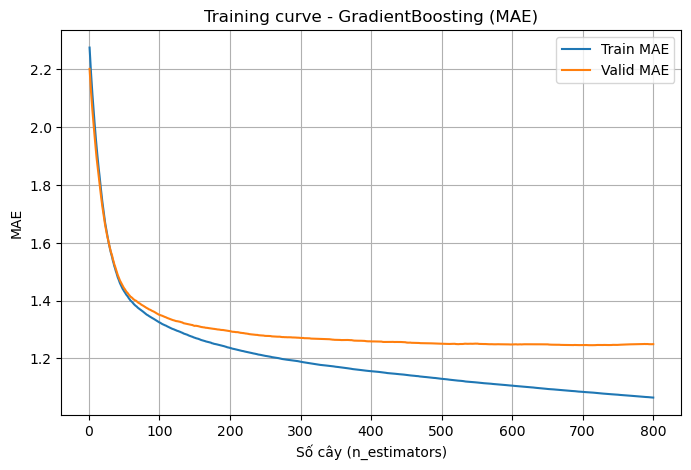

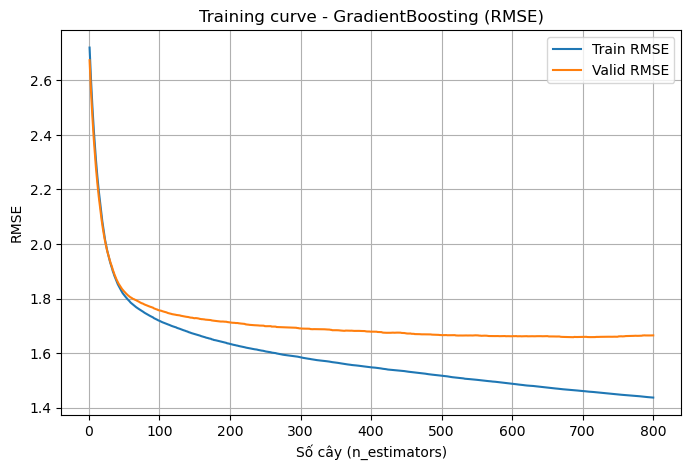

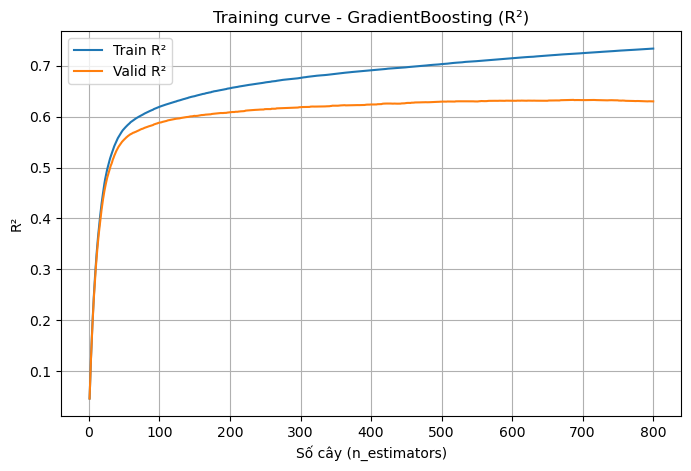

In [30]:
# =======================================
# 6c. Plot training curves cho GradientBoosting
# =======================================

# MAE train vs valid
plt.figure(figsize=(8, 5))
plt.plot(stages, train_mae_list, label="Train MAE")
plt.plot(stages, valid_mae_list, label="Valid MAE")
plt.xlabel("Số cây (n_estimators)")
plt.ylabel("MAE")
plt.title("Training curve - GradientBoosting (MAE)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Training curve - GradientBoosting (MAE).png"))
plt.show()

# RMSE train vs valid
plt.figure(figsize=(8, 5))
plt.plot(stages, train_rmse_list, label="Train RMSE")
plt.plot(stages, valid_rmse_list, label="Valid RMSE")
plt.xlabel("Số cây (n_estimators)")
plt.ylabel("RMSE")
plt.title("Training curve - GradientBoosting (RMSE)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Training curve - GradientBoosting (RMSE).png"))
plt.show()

# R² train vs valid
plt.figure(figsize=(8, 5))
plt.plot(stages, train_r2_list, label="Train R²")
plt.plot(stages, valid_r2_list, label="Valid R²")
plt.xlabel("Số cây (n_estimators)")
plt.ylabel("R²")
plt.title("Training curve - GradientBoosting (R²)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Training curve - GradientBoosting (R²).png"))
plt.show()


In [31]:
# =======================================
# 6d. Learning curve cho GradientBoosting (MAE ~ training size)
# =======================================

train_fracs = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]  # tỷ lệ dữ liệu train sử dụng
lc_results = []

# Để reproducible
rng = np.random.RandomState(42)
n_total = len(X)

for frac in train_fracs:
    n_sub = int(n_total * frac)
    idx_sub = rng.choice(n_total, size=n_sub, replace=False)

    X_sub = X.iloc[idx_sub]
    y_sub = y.iloc[idx_sub]

    # Split train/valid bên trong subset
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_sub, y_sub, test_size=0.2, random_state=42
    )

    gb_lc = GradientBoostingRegressor(
        n_estimators=best_n_estimators if best_n_estimators is not None else 300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
    gb_lc.fit(X_tr, y_tr)

    # Train metrics
    y_tr_pred = gb_lc.predict(X_tr)
    mae_tr = mean_absolute_error(y_tr, y_tr_pred)
    rmse_tr = np.sqrt(mean_squared_error(y_tr, y_tr_pred))
    r2_tr = r2_score(y_tr, y_tr_pred)

    # Valid metrics
    y_val_pred = gb_lc.predict(X_val)
    mae_val = mean_absolute_error(y_val, y_val_pred)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2_val = r2_score(y_val, y_val_pred)

    lc_results.append({
        "train_frac": frac,
        "n_train": len(X_tr),
        "MAE_train": mae_tr,
        "RMSE_train": rmse_tr,
        "R2_train": r2_tr,
        "MAE_valid": mae_val,
        "RMSE_valid": rmse_val,
        "R2_valid": r2_val
    })

    print(f"[LearningCurve] frac={frac:.1f} | n_train={len(X_tr)} | "
          f"MAE_valid={mae_val:.4f}, RMSE_valid={rmse_val:.4f}, R2_valid={r2_val:.4f}")

lc_df = pd.DataFrame(lc_results)
lc_df


[LearningCurve] frac=0.1 | n_train=386 | MAE_valid=1.7672, RMSE_valid=2.2550, R2_valid=0.3783
[LearningCurve] frac=0.2 | n_train=772 | MAE_valid=1.4590, RMSE_valid=1.9209, R2_valid=0.5546
[LearningCurve] frac=0.4 | n_train=1545 | MAE_valid=1.2410, RMSE_valid=1.6947, R2_valid=0.6648
[LearningCurve] frac=0.6 | n_train=2318 | MAE_valid=1.1687, RMSE_valid=1.5808, R2_valid=0.6483
[LearningCurve] frac=0.8 | n_train=3091 | MAE_valid=1.2118, RMSE_valid=1.6169, R2_valid=0.6646
[LearningCurve] frac=1.0 | n_train=3864 | MAE_valid=1.2644, RMSE_valid=1.6863, R2_valid=0.6206


,train_frac,n_train,MAE_train,RMSE_train,R2_train,MAE_valid,RMSE_valid,R2_valid
0,0.1,386,0.612454,0.879359,0.895909,1.767192,2.254972,0.378339
1,0.2,772,0.765910,1.053677,0.853455,1.459024,1.920897,0.554601
2,0.4,1545,0.946722,1.279651,0.782261,1.241005,1.694735,0.664757
3,0.6,2318,1.005685,1.352415,0.764826,1.168728,1.580799,0.648345
4,0.8,3091,1.074894,1.443590,0.733560,1.211763,1.616940,0.664649
5,1.0,3864,1.075160,1.447359,0.729894,1.264352,1.686284,0.620577


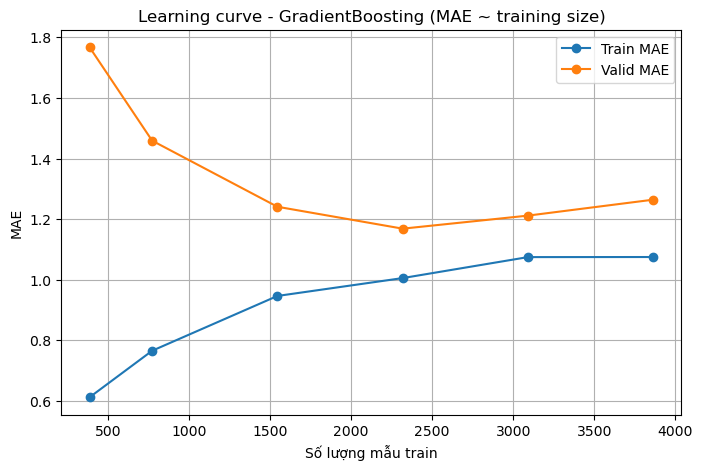

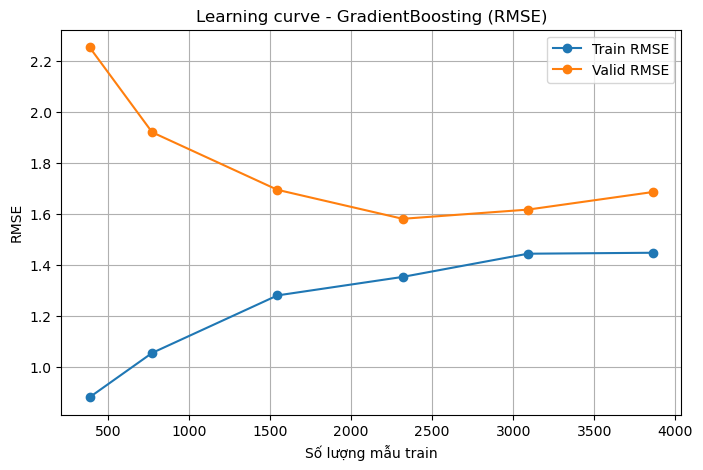

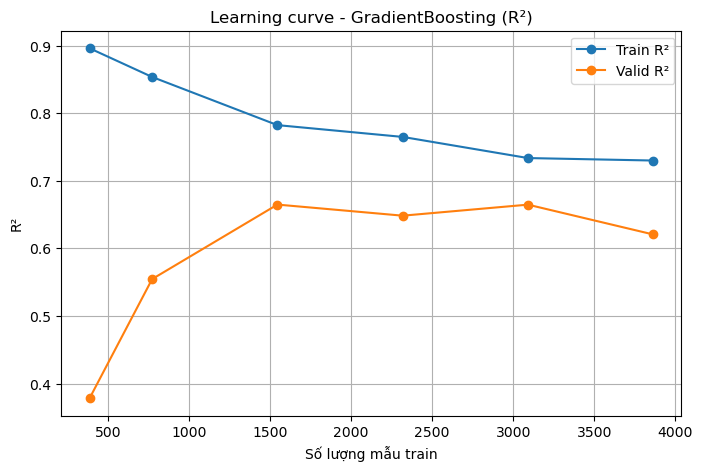

In [32]:
# MAE train & valid theo số lượng mẫu train
plt.figure(figsize=(8, 5))
plt.plot(lc_df["n_train"], lc_df["MAE_train"], marker="o", label="Train MAE")
plt.plot(lc_df["n_train"], lc_df["MAE_valid"], marker="o", label="Valid MAE")
plt.xlabel("Số lượng mẫu train")
plt.ylabel("MAE")
plt.title("Learning curve - GradientBoosting (MAE ~ training size)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Learning curve - GradientBoosting (MAE ~ training size).png"))
plt.show()

# (Optional) RMSE
plt.figure(figsize=(8, 5))
plt.plot(lc_df["n_train"], lc_df["RMSE_train"], marker="o", label="Train RMSE")
plt.plot(lc_df["n_train"], lc_df["RMSE_valid"], marker="o", label="Valid RMSE")
plt.xlabel("Số lượng mẫu train")
plt.ylabel("RMSE")
plt.title("Learning curve - GradientBoosting (RMSE)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Learning curve - GradientBoosting (RMSE).png"))
plt.show()

# (Optional) R²
plt.figure(figsize=(8, 5))
plt.plot(lc_df["n_train"], lc_df["R2_train"], marker="o", label="Train R²")
plt.plot(lc_df["n_train"], lc_df["R2_valid"], marker="o", label="Valid R²")
plt.xlabel("Số lượng mẫu train")
plt.ylabel("R²")
plt.title("Learning curve - GradientBoosting (R²)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Learning curve - GradientBoosting (R²).png"))
plt.show()


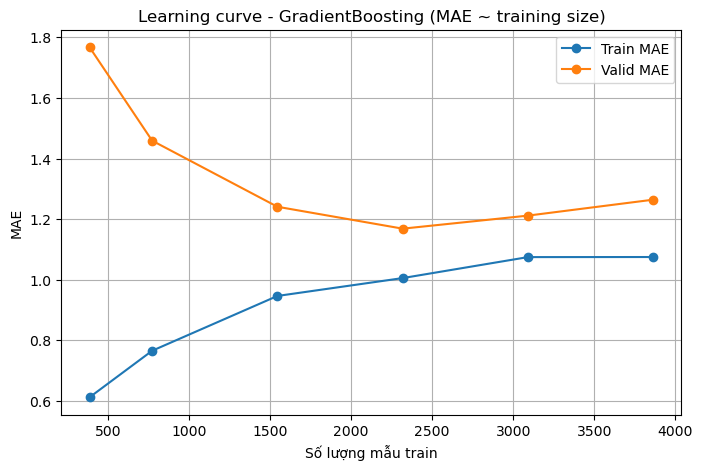

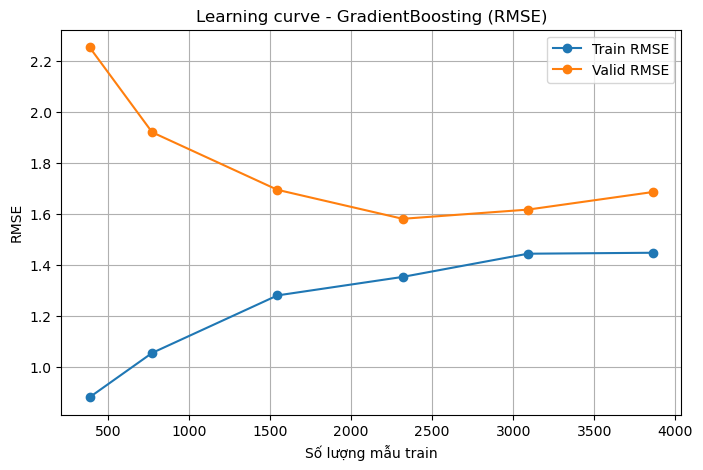

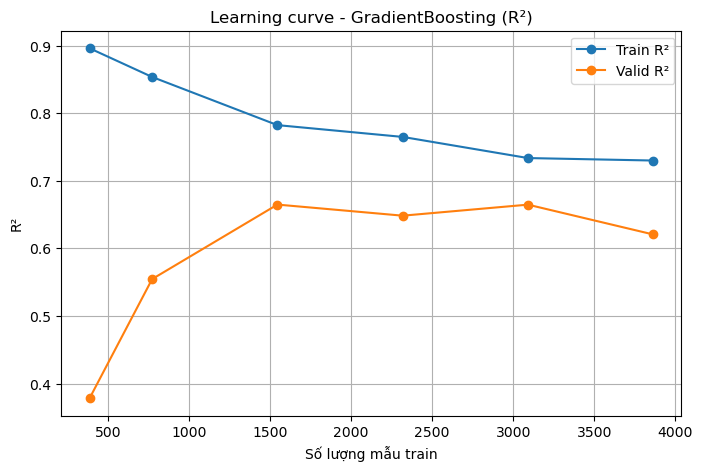

In [33]:
# MAE train & valid theo số lượng mẫu train
plt.figure(figsize=(8, 5))
plt.plot(lc_df["n_train"], lc_df["MAE_train"], marker="o", label="Train MAE")
plt.plot(lc_df["n_train"], lc_df["MAE_valid"], marker="o", label="Valid MAE")
plt.xlabel("Số lượng mẫu train")
plt.ylabel("MAE")
plt.title("Learning curve - GradientBoosting (MAE ~ training size)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Learning curve - GradientBoosting (MAE ~ training size).png"))
plt.show()

# (Optional) RMSE
plt.figure(figsize=(8, 5))
plt.plot(lc_df["n_train"], lc_df["RMSE_train"], marker="o", label="Train RMSE")
plt.plot(lc_df["n_train"], lc_df["RMSE_valid"], marker="o", label="Valid RMSE")
plt.xlabel("Số lượng mẫu train")
plt.ylabel("RMSE")
plt.title("Learning curve - GradientBoosting (RMSE)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Learning curve - GradientBoosting (RMSE).png"))
plt.show()

# (Optional) R²
plt.figure(figsize=(8, 5))
plt.plot(lc_df["n_train"], lc_df["R2_train"], marker="o", label="Train R²")
plt.plot(lc_df["n_train"], lc_df["R2_valid"], marker="o", label="Valid R²")
plt.xlabel("Số lượng mẫu train")
plt.ylabel("R²")
plt.title("Learning curve - GradientBoosting (R²)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Learning curve - GradientBoosting (R²).png"))
plt.show()


In [34]:
# =======================================
# 8b. Inference với fallback dựa trên course_R2 (GradientBoosting)
# =======================================

# Map course_code -> R2 (GB) từ bảng metrics
course_r2_gb = df_course_gb.set_index("course_code")["R2"].to_dict()

# Đảm bảo baseline đã được fill trước đó
if "baseline_final_weighted" not in data.columns:
    data["baseline_final_weighted"] = np.nan

baseline_mean_all = data["baseline_final_weighted"].mean()
data["baseline_final_weighted"] = data["baseline_final_weighted"].fillna(baseline_mean_all)

# Gắn course_R2_gb vào từng dòng
data["course_R2_gb"] = data["course_code"].map(course_r2_gb)

# Ngưỡng fallback (bạn có thể chỉnh)
HIGH_R2 = 0.60   # tin model
MID_R2 = 0.30    # tin vừa vừa, dùng blend

# Mặc định: nếu không có R2 (course mới), xem như low-confidence
data["course_R2_gb"] = data["course_R2_gb"].fillna(-999)

# Khởi tạo cột final_pred & source & confidence
data["final_pred"] = np.nan
data["pred_source"] = "unknown"
data["confidence_level"] = "unknown"

# Các mask theo R2
mask_high = data["course_R2_gb"] >= HIGH_R2           # tin model
mask_mid  = (data["course_R2_gb"] >= MID_R2) & (data["course_R2_gb"] < HIGH_R2)
mask_low  = data["course_R2_gb"] < MID_R2             # fallback baseline / course mới

# HIGH: dùng thẳng pred_final_gb
data.loc[mask_high, "final_pred"] = data.loc[mask_high, "pred_final_gb"]
data.loc[mask_high, "pred_source"] = "gb_model"
data.loc[mask_high, "confidence_level"] = "high"

# MID: blend giữa model và baseline (70% model, 30% baseline)
alpha = 0.7
blend_mid = (
    alpha * data.loc[mask_mid, "pred_final_gb"] +
    (1 - alpha) * data.loc[mask_mid, "baseline_final_weighted"]
)
data.loc[mask_mid, "final_pred"] = blend_mid
data.loc[mask_mid, "pred_source"] = "gb_baseline_blend"
data.loc[mask_mid, "confidence_level"] = "medium"

# LOW: fallback hoàn toàn về baseline
data.loc[mask_low, "final_pred"] = data.loc[mask_low, "baseline_final_weighted"]
data.loc[mask_low, "pred_source"] = "baseline_only"
data.loc[mask_low, "confidence_level"] = "low"

# ✅ Tới đây, cột final_pred là prediction cuối cùng sau fallback
# Bạn có thể xem nhanh phân bố theo confidence_level:
print("\nSố lượng prediction theo confidence_level:")
print(data["confidence_level"].value_counts())

# Lưu file mới với final_pred
pred_csv_path_fallback = os.path.join(OUTPUT_DIR, "predictions_with_fallback_v2.csv")
data.to_csv(pred_csv_path_fallback, index=False, encoding="utf-8-sig")
print(f"Đã lưu dự đoán với fallback vào: {pred_csv_path_fallback}")



Số lượng prediction theo confidence_level:
confidence_level
low       1869
high      1722
medium    1239
Name: count, dtype: int64
Đã lưu dự đoán với fallback vào: ./output_final_v2\predictions_with_fallback_v2.csv


In [35]:
import joblib

artifacts = {
    "gb_model": gb_model_es,
    "feature_cols": feature_cols,
    "mask_cols": mask_cols,
    "course_dummy_cols": list(course_dummies.columns),
    "baseline_fill_value": baseline_fill_value,  # ✅ thêm dòng này
}

model_path = os.path.join(OUTPUT_DIR, "model_artifacts_gb_rf.joblib")
joblib.dump(artifacts, model_path)
print(f"Đã lưu model & artifacts vào: {model_path}")


Đã lưu model & artifacts vào: ./output_final_v2\model_artifacts_gb_rf.joblib


In [36]:
model_path_pkl = os.path.join(OUTPUT_DIR, "model_artifacts_gb_rf.pkl")
joblib.dump(artifacts, model_path_pkl)
print(f"Đã lưu model & artifacts (pkl) vào: {model_path_pkl}")


Đã lưu model & artifacts (pkl) vào: ./output_final_v2\model_artifacts_gb_rf.pkl


In [37]:
def build_X_from_df_for_inference(
    df: pd.DataFrame,
    artifacts: dict,
    weights_by_course: dict
) -> (pd.DataFrame, pd.DataFrame):
    """
    df: DataFrame đã chuẩn hóa schema (output của load_and_process_course_file)
    artifacts: dict load từ joblib (chứa feature_cols, mask_cols, course_dummy_cols, baseline_fill_value, ...)
    weights_by_course: weights_used đã load sẵn

    Trả về:
      - df_features: df sau khi thêm baseline_final_weighted (giữ meta + features)
      - X_new: ma trận feature đúng shape cho model.predict(...)
    """
    feature_cols = artifacts["feature_cols"]
    mask_cols = artifacts["mask_cols"]
    course_dummy_cols = artifacts["course_dummy_cols"]
    baseline_fill_value = artifacts.get("baseline_fill_value", 5.0)

    # Thêm baseline_final_weighted cho df (nếu có weight)
    df = add_baseline_from_weights(df, weights_by_course)

    # Nếu course này không có weight → baseline sẽ NaN → fill = baseline_fill_value của TRAIN
    if "baseline_final_weighted" not in df.columns:
        df["baseline_final_weighted"] = np.nan

    df["baseline_final_weighted"] = df["baseline_final_weighted"].fillna(baseline_fill_value)

    # Numeric features: điểm + mask + baseline
    X_num = df[feature_cols + mask_cols + ["baseline_final_weighted"]].copy()
    X_num = X_num.fillna(0.0)

    # One-hot course_code cho file mới
    course_dummies_new = pd.get_dummies(df["course_code"], prefix="course")

    # Đồng bộ cột one-hot với lúc train
    for col in course_dummy_cols:
        if col not in course_dummies_new.columns:
            course_dummies_new[col] = 0
    course_dummies_new = course_dummies_new[course_dummy_cols]

    X_new = pd.concat([X_num, course_dummies_new], axis=1)
    return df, X_new


In [38]:
import joblib
import pandas as pd
import os

# 1. Load artifacts & weights
artifacts = joblib.load(os.path.join(OUTPUT_DIR, "model_artifacts_gb_rf.joblib"))
weights_by_course_inf = load_weights(WEIGHTS_FILE)

# 2. Nhận file upload (ở đây ví dụ là CMU-CS 462.csv)
uploaded_path = os.path.join(DATA_DIR, "CMU-CS 462.csv")  # thay bằng path thực tế

# 3. Chuẩn hóa file
df_course = load_and_process_course_file(uploaded_path)

# 4. Build X_new
df_features, X_new = build_X_from_df_for_inference(
    df_course,
    artifacts=artifacts,
    weights_by_course=weights_by_course_inf
)

# 5. Chọn model (GB làm model chính)
gb_model_loaded = artifacts["gb_model"]
pred_final = gb_model_loaded.predict(X_new)

df_features["pred_final_gb"] = pred_final

# 6. (Tùy bạn) apply thêm fallback theo R² nếu muốn, hoặc dùng luôn pred_final_gb
output_pred_path = os.path.join(OUTPUT_DIR, "pred_for_uploaded_CMU_CS_462_fixed.csv")
df_features.to_csv(output_pred_path, index=False, encoding="utf-8-sig")
print("Đã lưu dự đoán:", output_pred_path)


Đã load weights cho 47 course.
Đang đọc file: output_final_fixed\CMU-CS 462.csv
Đã lưu dự đoán: ./output_final_v2\pred_for_uploaded_CMU_CS_462_fixed.csv


In [ ]:

# =======================================
# 9. Lưu kết quả vào MongoDB (optional)
# =======================================

def save_predictions_to_mongodb(
    df: pd.DataFrame,
    mongo_uri: str = "mongodb://localhost:27017",
    db_name: str = "student_scores",
    collection_name: str = "predictions_v2_fallback"
):
    client = MongoClient(mongo_uri)
    db = client[db_name]
    coll = db[collection_name]

    records = []

    for _, row in df.iterrows():
        record = {
            "student_id": row.get("student_id"),
            "course_code": row.get("course_code"),
            "no": row.get("no"),
            "scores": {feat: row.get(feat) for feat in CANONICAL_FEATURES},
            "masks": {f"{feat}_mask": row.get(f"{feat}_mask") for feat in CANONICAL_FEATURES},
            "baseline_final_weighted": row.get("baseline_final_weighted"),
            "pred_final_rf": row.get("pred_final_rf"),
            "pred_final_gb": row.get("pred_final_gb"),
            # ✅ prediction cuối cùng sau fallback
            "final_pred": row.get("final_pred"),
            "pred_source": row.get("pred_source"),
            "confidence_level": row.get("confidence_level"),
            "created_at": datetime.utcnow()
        }
        if not pd.isna(row.get(TARGET_COL)):
            record["final_true"] = row.get(TARGET_COL)
        records.append(record)

    if records:
        result = coll.insert_many(records)
        print(f"Đã insert {len(result.inserted_ids)} documents vào MongoDB.")
    else:
        print("Không có record nào để insert.")

# Gọi thử (nếu bạn có MongoDB đang chạy)
try:
    save_predictions_to_mongodb(data)
except Exception as e:
    print("Lỗi khi lưu MongoDB (kiểm tra lại URI/connection):", e)


Shape data: (4830, 32)
     student_id course_code  no  attend  quiz  quiz2  midterm  homework  \
0  2.821128e+10     CHE 101   1     NaN   NaN    NaN      6.0       6.0   
1  2.821905e+10     CHE 101   2     NaN   NaN    NaN     10.0      10.0   
2  2.721132e+10     CHE 101   3     NaN   NaN    NaN     10.0      10.0   

   homework1  homework2  ...  homework1_mask  homework2_mask  \
0        NaN        NaN  ...               0               0   
1        NaN        NaN  ...               0               0   
2        NaN        NaN  ...               0               0   

   group_project_mask  individual_project_mask  practice_mask  regular_mask  \
0                   0                        0              0             0   
1                   0                        0              0             0   
2                   0                        0              0             0   

   speech_and_discussion_mask  project_mask  final_mask  \
0                           1             0

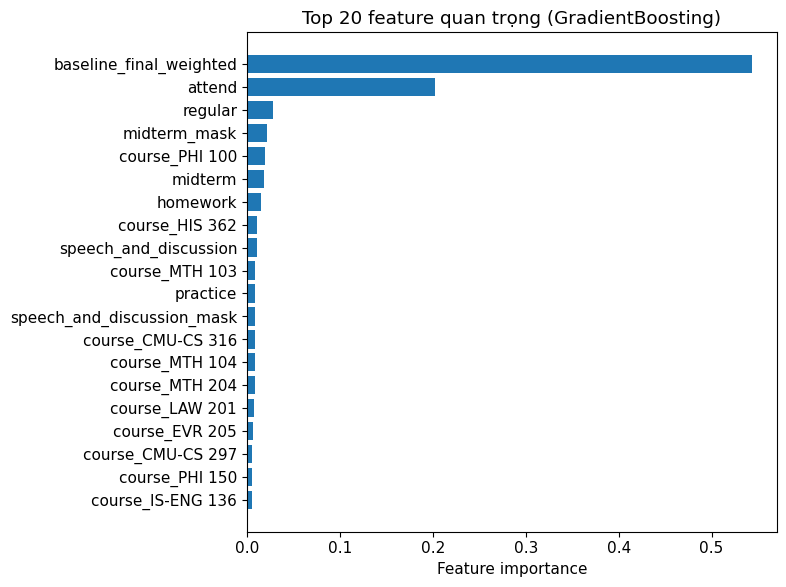

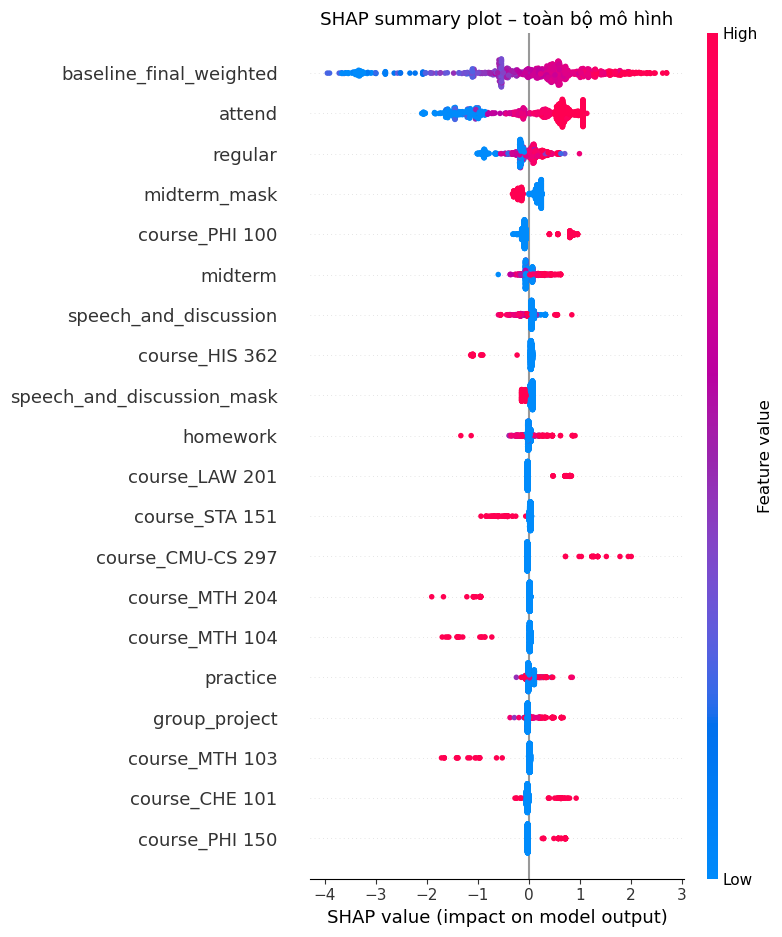


Số sinh viên bị coi là outlier (|z| > 2): 276
Top 10 outlier:
        student_id course_code  final_true  final_pred     error   error_z
2535  3.021915e+10     LAW 201         0.0    8.384973  8.384973  5.648030
4164  2.920734e+10     POS 151         0.0    7.617967  7.617967  5.131795
1167  2.821025e+10     COM 141         0.0    7.389191  7.389191  4.977816
1321  2.820461e+10      CS 201         0.0    7.246995  7.246995  4.882111
1160  2.821231e+10     COM 141         0.0    7.159345  7.159345  4.823119
1787  2.921116e+10     EVR 205         0.0    7.064872  7.064872  4.759533
4351  2.920652e+10     POS 351         9.3    2.411974 -6.888026 -4.631491
4174  2.721134e+10     POS 151         0.0    6.679230  6.679230  4.499976
1253  2.921110e+10     COM 142         0.0    6.473239  6.473239  4.361333
2068  2.920726e+10     HIS 362         0.0    6.294487  6.294487  4.241024


In [3]:
# ============================================================
# Notebook: XAI cho mô hình dự đoán điểm cuối kỳ
# - Dùng dữ liệu synthetic_training_sample_v2.csv
# - Train lại GradientBoosting giống pipeline hiện tại
# - Áp dụng XAI (Feature Importance, SHAP, Outlier)
# ============================================================

# -----------------------------
# 0. Import thư viện & config
# -----------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# XAI
import shap

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42

# ---------------------------------------------------------
# 1. Load dữ liệu synthetic_training_sample_v2.csv
#    (đã được tạo ở notebook training trước đó)
# ---------------------------------------------------------
DATA_PATH = "./output_final_v2/synthetic_training_sample_v2.csv"  # sửa lại nếu bạn lưu nơi khác

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Không tìm thấy file: {DATA_PATH}")

data = pd.read_csv(DATA_PATH)
print("Shape data:", data.shape)
print(data.head(3))

# ---------------------------------------------------------
# 2. Chuẩn bị feature giống pipeline huấn luyện
# ---------------------------------------------------------

# Cột target
TARGET_COL = "final"

# Danh sách feature điểm (không gồm final)
FEATURE_SCORE_COLS = [
    "attend",
    "quiz",
    "quiz2",
    "midterm",
    "homework",
    "homework1",
    "homework2",
    "group_project",
    "individual_project",
    "practice",
    "regular",
    "speech_and_discussion",
    "project"
]

# Toàn bộ canonical features (gồm final, để tạo mask_name)
CANONICAL_FEATURES = FEATURE_SCORE_COLS + [TARGET_COL]

# Tạo danh sách cột mask
mask_cols = [f"{f}_mask" for f in CANONICAL_FEATURES]

# Chỉ dùng dòng có final để train/evaluate XAI
data_train = data[~data[TARGET_COL].isna()].copy()
print("Số dòng có final (train XAI):", len(data_train))

# Xử lý baseline_final_weighted: fill NaN bằng mean hoặc 5.0 nếu tất cả NaN
if "baseline_final_weighted" not in data_train.columns:
    data_train["baseline_final_weighted"] = np.nan

baseline_fill_value = data_train["baseline_final_weighted"].mean()
if np.isnan(baseline_fill_value):
    baseline_fill_value = 5.0

data_train["baseline_final_weighted"] = data_train["baseline_final_weighted"].fillna(baseline_fill_value)

# Numeric features = điểm + mask + baseline
X_num = data_train[FEATURE_SCORE_COLS + mask_cols + ["baseline_final_weighted"]].copy()
X_num = X_num.fillna(0.0)

# One-hot course_code
course_dummies = pd.get_dummies(data_train["course_code"], prefix="course")

X = pd.concat([X_num, course_dummies], axis=1)
y = data_train[TARGET_COL].astype(float)

print("Shape X:", X.shape, "| Shape y:", y.shape)

# Lưu lại index để biết course_code khi đánh giá / XAI
idx_all = data_train.index.to_numpy()

X_train, X_valid, y_train, y_valid, idx_train, idx_valid = train_test_split(
    X, y, idx_all, test_size=0.2, random_state=RANDOM_STATE
)

# ---------------------------------------------------------
# 3. Train GradientBoosting (giống notebook trước)
#    – có theo dõi history để sau này vẽ training curve nếu cần
# ---------------------------------------------------------
gb = GradientBoostingRegressor(
    n_estimators=800,      # train nhiều, rồi chọn early-stopping nếu muốn
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE
)

gb.fit(X_train, y_train)

y_pred_valid = gb.predict(X_valid)
mae = mean_absolute_error(y_valid, y_pred_valid)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred_valid))
r2 = r2_score(y_valid, y_pred_valid)

print("==== Hiệu năng GradientBoosting cho XAI ====")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R^2  : {r2:.4f}")

# ---------------------------------------------------------
# 4. Global Feature Importance (toàn mô hình)
# ---------------------------------------------------------
importances = gb.feature_importances_
feat_names = X.columns

imp_df = pd.DataFrame({
    "feature": feat_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTop 20 feature quan trọng nhất (theo GradientBoosting):")
print(imp_df.head(20))

# Vẽ barplot top 20 feature
top_k = 20
imp_top = imp_df.head(top_k).iloc[::-1]  # đảo ngược để vẽ từ nhỏ lên lớn

plt.figure(figsize=(8, 6))
plt.barh(imp_top["feature"], imp_top["importance"])
plt.xlabel("Feature importance")
plt.title("Top 20 feature quan trọng (GradientBoosting)")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. SHAP – Global Explainability (Summary Plot)
# ---------------------------------------------------------
# Nếu chưa cài shap: !pip install shap

shap.initjs()

# Lấy sample để SHAP nhanh hơn (ví dụ tối đa 1000 dòng)
sample_size = min(1000, X_train.shape[0])
X_shap = X_train.sample(sample_size, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(gb)
shap_values = explainer.shap_values(X_shap)

# Summary plot: thể hiện feature nào kéo điểm lên/xuống
plt.title("SHAP summary plot – toàn bộ mô hình")
shap.summary_plot(shap_values, X_shap, show=True)

# ---------------------------------------------------------
# 6. SHAP per-course: giải thích theo từng môn học
# ---------------------------------------------------------

def shap_for_course(course_code: str, max_samples: int = 200):
    """
    Vẽ SHAP summary plot cho riêng một course_code.
    Giúp giảng viên môn đó xem mô hình đang dựa vào điểm nào.
    """
    # Lấy index thuộc course_code trong tập data_train
    idx_course = data_train.index[data_train["course_code"] == course_code]

    if len(idx_course) == 0:
        print(f"Không tìm thấy course_code = {course_code}")
        return

    # Lấy giao với index train (tránh dùng valid nếu bạn muốn)
    idx_course_train = [i for i in idx_course if i in idx_train]

    if len(idx_course_train) == 0:
        print(f"Course {course_code} không có trong tập train (chỉ có ở valid).")
        return

    X_course = X.loc[idx_course_train]

    # Sample cho nhanh
    if len(X_course) > max_samples:
        X_course = X_course.sample(max_samples, random_state=RANDOM_STATE)

    shap_values_course = explainer.shap_values(X_course)

    print(f"SHAP cho course {course_code} – số mẫu: {len(X_course)}")
    shap.summary_plot(shap_values_course, X_course, show=True)

# Ví dụ: xem giải thích cho một số môn (bạn đổi mã môn tuỳ ý)
# shap_for_course("DTE-IS 102")
# shap_for_course("CHE 101")
# shap_for_course("PHI 100")

# ---------------------------------------------------------
# 7. SHAP local cho một sinh viên cụ thể
# ---------------------------------------------------------

def explain_student(course_code: str, student_id: str):
    """
    In ra:
      - final thực tế, final dự đoán
      - baseline_final_weighted
      - top feature SHAP (dạng bảng)
    Và vẽ waterfall plot (nếu môi trường hỗ trợ).
    """
    # Lọc data_train theo course và student_id
    df_sub = data_train[
        (data_train["course_code"] == course_code) &
        (data_train["student_id"].astype(str) == str(student_id))
    ]

    if df_sub.empty:
        print(f"Không tìm thấy sinh viên {student_id} trong course {course_code}.")
        return

    # Lấy dòng đầu tiên nếu trùng
    row = df_sub.iloc[0]
    idx = row.name

    # Chuẩn bị feature vector
    x_row = X.loc[[idx]]  # giữ dạng DataFrame 1 dòng

    # Dự đoán
    final_true = row[TARGET_COL]
    baseline = row.get("baseline_final_weighted", np.nan)
    final_pred = gb.predict(x_row)[0]

    print("======================================")
    print(f"Giải thích cho sinh viên: {student_id} | Course: {course_code}")
    print("final thật         :", final_true)
    print("baseline (weights) :", baseline)
    print("final dự đoán (GB) :", final_pred)
    print("Sai số             :", final_pred - final_true)
    print("======================================")

    # SHAP cho 1 sample
    shap_val_row = explainer.shap_values(x_row)[0]  # mảng dài = số feature
    feature_names = x_row.columns

    # Bảng top feature theo |shap|
    df_shap_row = pd.DataFrame({
        "feature": feature_names,
        "value": x_row.values[0],
        "shap_value": shap_val_row
    })
    df_shap_row["abs_shap"] = df_shap_row["shap_value"].abs()
    df_shap_row = df_shap_row.sort_values("abs_shap", ascending=False)

    print("\nTop 10 feature ảnh hưởng tới dự đoán:")
    print(df_shap_row.head(10)[["feature", "value", "shap_value"]])

    # Waterfall plot (nếu bạn dùng Jupyter Notebook)
    shap.plots._waterfall.waterfall_legacy(
        shap.Explanation(values=shap_val_row,
                         base_values=explainer.expected_value,
                         data=x_row.values[0],
                         feature_names=feature_names)
    )

# Ví dụ gọi:
# explain_student("DTE-IS 102", "28211280315")


# ---------------------------------------------------------
# 8. Phân tích outlier: sinh viên dự đoán lệch nhiều
# ---------------------------------------------------------

# Dự đoán trên toàn bộ data_train
y_pred_all = gb.predict(X)
errors = y_pred_all - y.values

df_err = pd.DataFrame({
    "student_id": data_train["student_id"],
    "course_code": data_train["course_code"],
    "final_true": y.values,
    "final_pred": y_pred_all,
    "error": errors
}, index=data_train.index)

# Tính z-score (chuẩn hóa sai số)
err_mean = df_err["error"].mean()
err_std = df_err["error"].std() if df_err["error"].std() > 0 else 1.0
df_err["error_z"] = (df_err["error"] - err_mean) / err_std

# Lọc outlier mạnh (|z| > 2)
df_outlier = df_err[df_err["error_z"].abs() > 2].copy()
df_outlier = df_outlier.sort_values("error_z", key=lambda s: s.abs(), ascending=False)

print("\nSố sinh viên bị coi là outlier (|z| > 2):", len(df_outlier))
print("Top 10 outlier:")
print(df_outlier.head(10))

# Bạn có thể chọn một trong các outlier này để explain chi tiết:
# row0 = df_outlier.iloc[0]
# explain_student(row0["course_code"], row0["student_id"])
